# Handling missing data

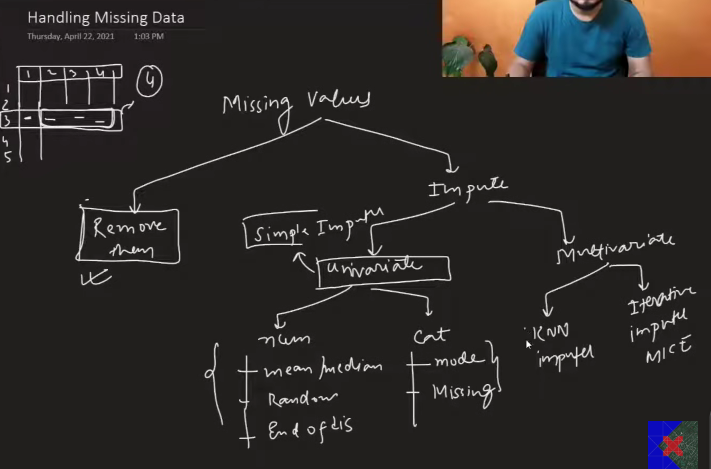

- 2 ways to handle missing data:
    - **Complete case analysis**: only use rows with no missing values (remove rows with missing values, but here problem is that we lose a lot of data, bcoz maybe in row just one value is missing, but rest of the values are there, so we can use that row, but in complete case analysis we will remove that row)
    - **Imputation**: fill in missing values with some strategy

We will be covering the whole topic in 5 lectures:
1. Complete case analysis
2. Simple Imputator
3. KNN Imputator
4. Iterative Imputator
5. Missing indicator

# Complete case analysis

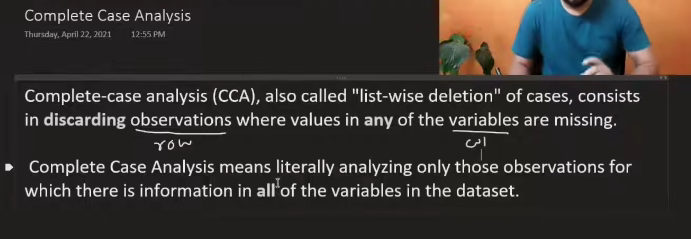

# Assumptions of complete case analysis
- Data is missing completely at random (MCAR): the probability of a value being missing is independent of both observed and unobserved data. In other words, the missingness is purely random and does not depend on any other variables in the dataset.
- If the data is not MCAR, complete case analysis can lead to biased results as there might be change in distribution of the data after removing rows with missing values

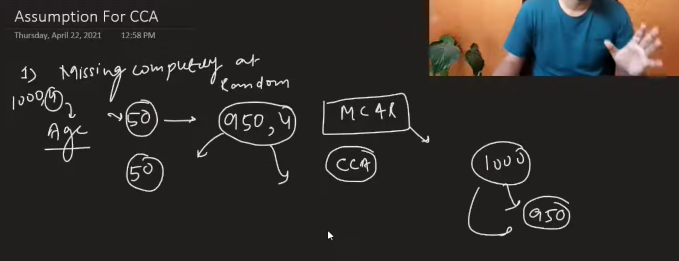

# Advantage/Disadvantage of complete case analysis

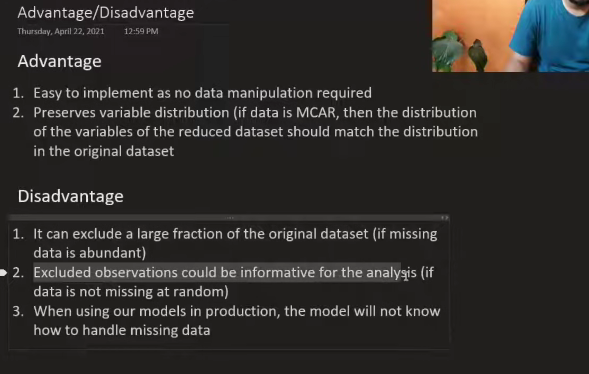

<span style="color:orange">We have to always check the distribution of the data before and after applying complete case analysis to ensure that the results are not biased.</span>


# When to use complete case analysis?

1. MCAR data: If the data is missing completely at random, complete case analysis can be a valid approach as it will not introduce bias into the results.

2. Small proportion of missing data: If the proportion of missing data is small (e.g., less than 5%), complete case analysis may be acceptable as it will not significantly reduce the sample size or introduce bias.

(Let's say if 95% data is missing we can remove the column as well)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data_science_job.csv')

In [3]:
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
190,26099,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,12.0,10000+,Pvt Ltd,60.0,0.0
16402,9211,city_100,0.887,Female,Has relevent experience,no_enrollment,Graduate,No Major,5.0,NaN,NaN,12.0,0.0
18176,28839,city_114,0.926,Male,No relevent experience,Full time course,High School,NaN,2.0,100-500,Pvt Ltd,52.0,0.0
10916,121,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,9.0,1000-4999,Pvt Ltd,6.0,0.0
16718,12816,city_16,0.910,NaN,No relevent experience,no_enrollment,High School,NaN,4.0,NaN,NaN,52.0,0.0


In [6]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [8]:
df.isnull().mean() * 100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

- We will apply CCA considering the features only where < 5% missing values

In [9]:
df.shape

(19158, 13)

In [16]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'training_hours', 'target'],
      dtype='object')

In [ ]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols
# Columns where missing values are less than 5% and greater than 0%

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [ ]:
type(cols) # just to see the type of cols its list or dataframe

list

In [11]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
16146,0.890,Part time course,Masters,8.0,81.0
8032,0.776,no_enrollment,Masters,1.0,49.0
14758,0.896,no_enrollment,Masters,20.0,9.0
14299,0.843,no_enrollment,Graduate,10.0,28.0
331,0.865,no_enrollment,NaN,3.0,302.0


In [18]:
df[cols].shape

(19158, 5)

- Below step is very important to check how many rows we will be retaining after applying CCA, if we are retaining very less rows then we should not apply CCA

In [13]:
len(df[cols].dropna()) / len(df) # Percentage of rows that will be retained after dropping rows with missing values in the selected columns

0.8968577095730244

In [14]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

### Apply histogram on old and new data to check the distribution of the data before and after applying CCA

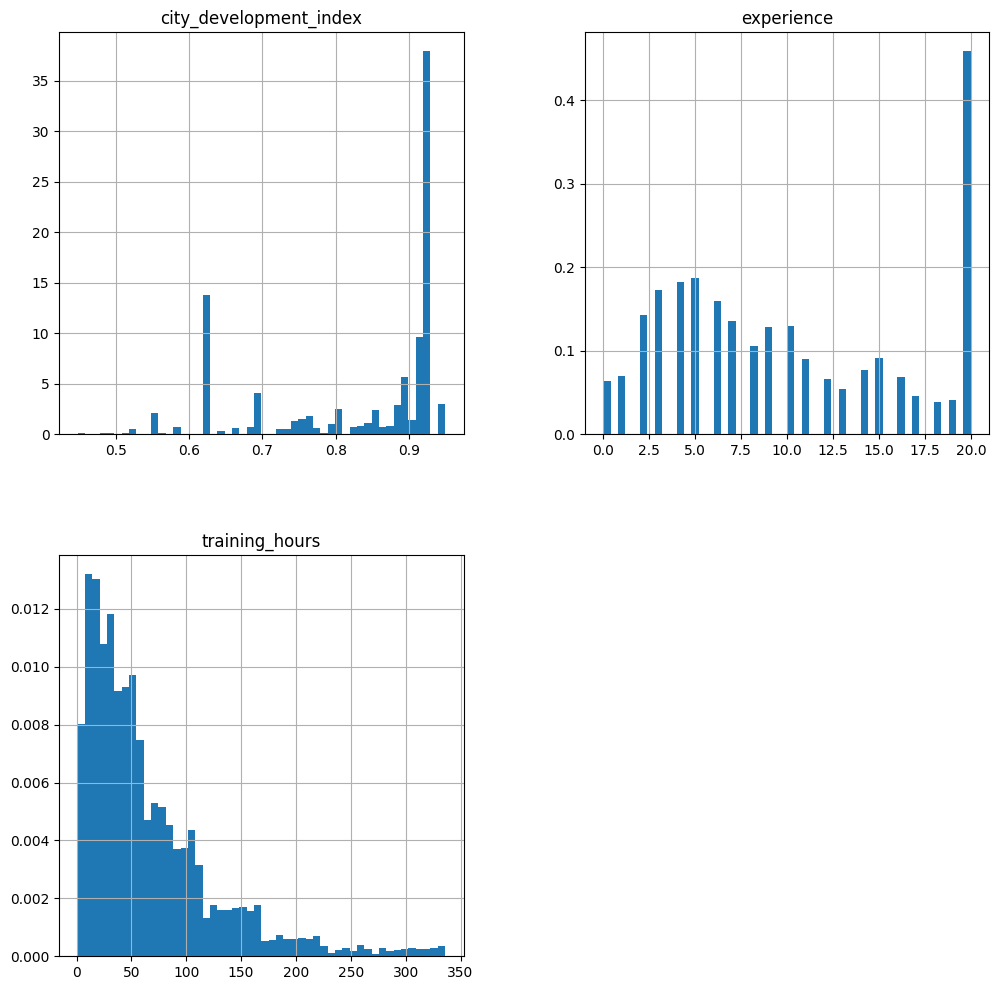

In [15]:
new_df.hist(bins=50, density=True, figsize=(12, 12))
plt.show()

<Axes: >

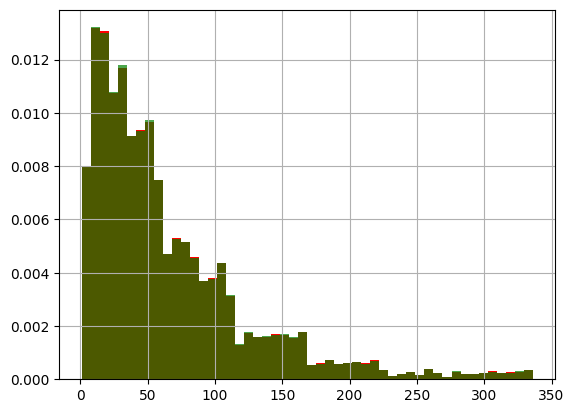

In [23]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['training_hours'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.7)

<Axes: ylabel='Density'>

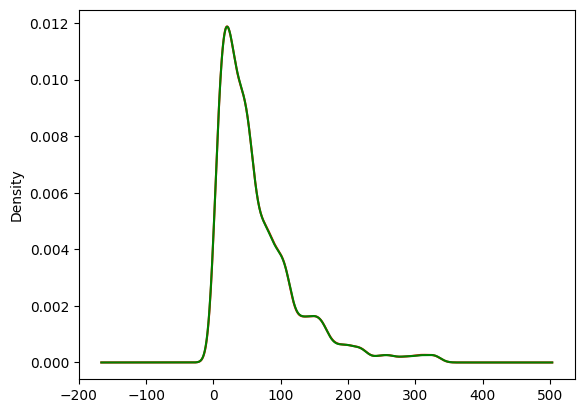

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='red')

# data after cca
new_df['training_hours'].plot.density(color='green')

- So in the above density plot red and green line overlaps,so we can say that the distribution of the data is not changing after applying CCA, so we can apply CCA on this dataset

- This also means that the data is missing completely at random (MCAR) 

<Axes: >

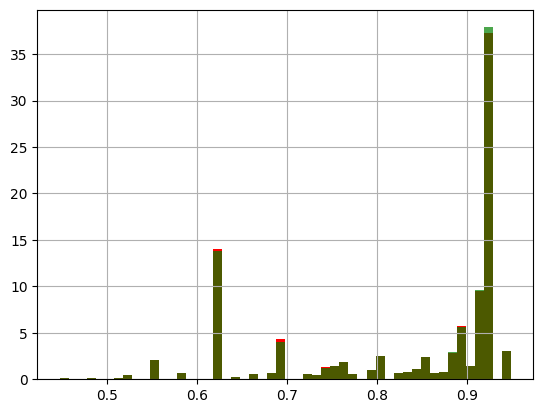

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['city_development_index'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.7)

<Axes: ylabel='Density'>

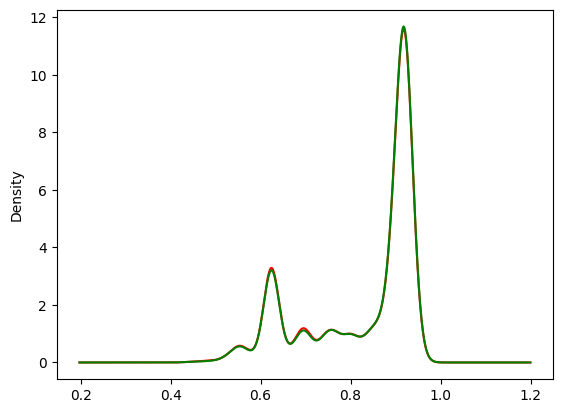

In [27]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].plot.density(color='red')

# data after cca
new_df['city_development_index'].plot.density(color='green')

<Axes: >

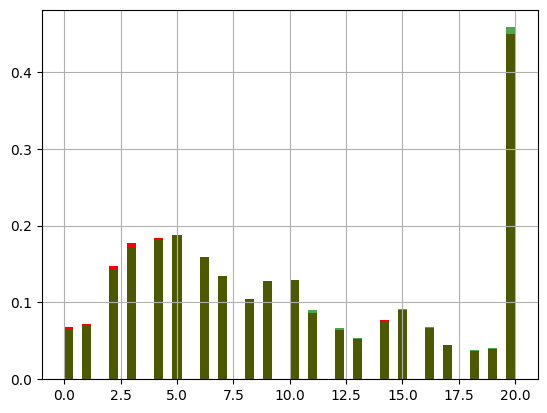

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.7)

<Axes: ylabel='Density'>

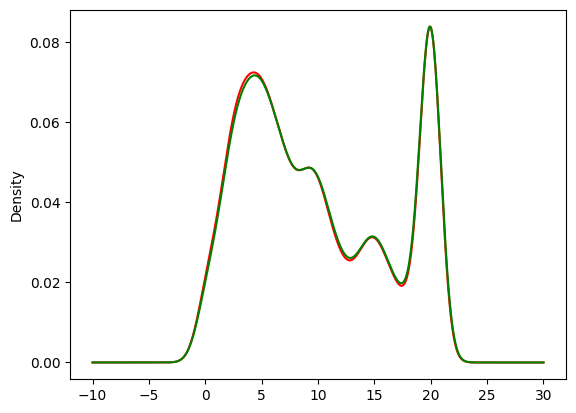

In [30]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].plot.density(color='red')

# data after cca
new_df['experience'].plot.density(color='green')

# For Categorical columns

- <span style="color:orange">We need to see if the ratio of categories for a column is similar before and after applying CCA </span>
- Here are 2 categorical columns: enrolled_university and education_level

In [31]:
df['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

In [32]:
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [33]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['enrolled_university'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [34]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['education_level'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
